In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
np.random.seed(42)

X_cat = np.random.randint(0, 100, (100, 64, 64))
X_dog = np.random.randint(150, 255, (100, 64, 64))

print("Cat data shape:", X_cat.shape)
print("Dog data shape:", X_dog.shape)

Cat data shape: (100, 64, 64)
Dog data shape: (100, 64, 64)


In [3]:
X = np.concatenate((X_cat, X_dog))

print("Total images:", X.shape)

Total images: (200, 64, 64)


In [4]:
y = np.array([0] * 100 + [1] * 100)

print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [5]:
X = X.reshape(X.shape[0], -1)

print("New shape:", X.shape)

New shape: (200, 4096)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 160
Testing images: 40


In [7]:
model = SVC(kernel="linear")

print("SVM model created")

SVM model created


In [8]:
model.fit(X_train, y_train)

print("SVM training completed!")

SVM training completed!


In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1
 1 1 0]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [11]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        21
         Dog       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [12]:
sample = X_test[0]

prediction = model.predict([sample])

if prediction[0] == 0:
    print("Prediction: CAT 🐱")
else:
    print("Prediction: DOG 🐶")

Prediction: CAT 🐱


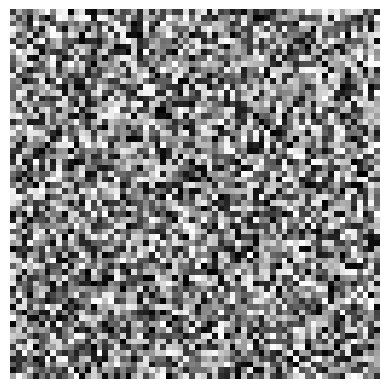

In [13]:
image = X_test[0].reshape(64, 64)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()